## **Tarea 1: Modelado Computacional de la Distribución Binomial**

La distribución **Binomial** modela el número de éxitos en ensayos independientes de **Bernoulli**, con una probabilidad de éxito $p$. Su PMF (Función de Masa de Probabilidad) está dada por:

$$P(X = x) = \binom{n}{x} p^x (1 - p)^{n-x}$$


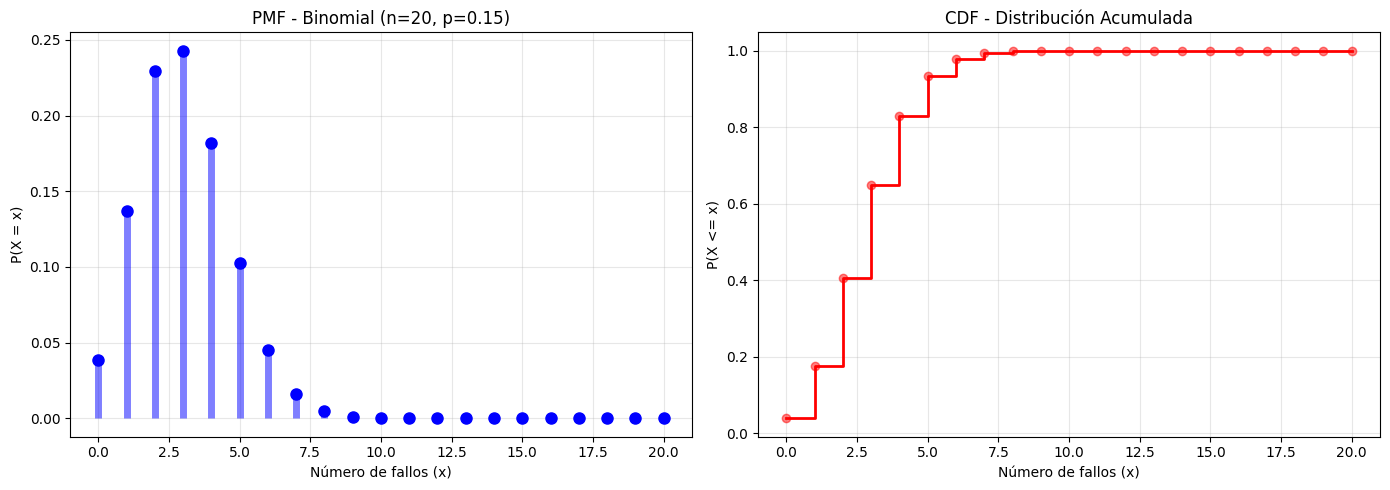

La probabilidad de tener 3 fallos o menos es: 0.6477


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros del modelo Binomial
n_ensayos = 20
p_falla = 0.15

# Dominio de la variable aleatoria (0 a n)
x = np.arange(0, n_ensayos + 1)

# Cálculo de PMF (Función de Masa) y CDF (Función Acumulada)
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
cdf_binomial = binom.cdf(x, n_ensayos, p_falla)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico PMF
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=0.5)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
ax[0].set_title(f'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, alpha=0.3)

# Gráfico CDF
ax[1].step(x, cdf_binomial, where='post', color='r', lw=2)
ax[1].plot(x, cdf_binomial, 'ro', alpha=0.5)
ax[1].set_title('CDF - Distribución Acumulada')
ax[1].set_xlabel('Número de fallos (x)')
ax[1].set_ylabel('P(X <= x)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo de probabilidad específica: P(X <= 3)
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de tener 3 fallos o menos es: {prob_max_3:.4f}")


---

## **Tarea 2: Modelado de la Distribución de Poisson (Eventos Raros)**

La distribución de **Poisson** modela el número de eventos que ocurren en un intervalo de tiempo o espacio continuo, con una tasa media conocida $\lambda$. Su PMF es:

$$P(X = x) = \frac{e^{-\lambda} \lambda^x}{x!}$$

Suponga que los servidores de la universidad en Loja reciben en promedio $\lambda = 4.5$ peticiones de acceso erróneas por minuto.

Basándose en la estructura del código de la Tarea 1, implemente la simulación utilizando `scipy.stats.poisson`. Grafique únicamente la PMF evaluando desde $x = 0$ hasta $x = 15$.

Calcule mediante código la probabilidad exacta de recibir exactamente 6 peticiones erróneas en un minuto: $P(X = 6)$.



La probabilidad exacta de recibir 6 peticiones en un minuto P(X=6) es: 0.1281


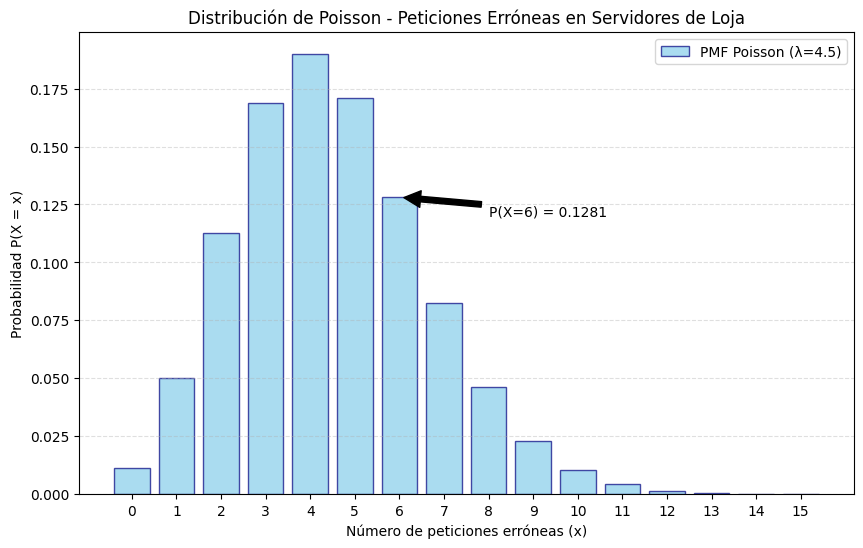

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Promedio de peticiones erróneas por minuto
lam = 4.5

# Calcular P(X = 6)
prob_6 = poisson.pmf(6, lam)
print(f"La probabilidad exacta de recibir 6 peticiones en un minuto P(X=6) es: {prob_6:.4f}")

# Rango de x desde 0 hasta 15 (como pide la tarea)
x = np.arange(0, 16)
pmf_values = poisson.pmf(x, lam)

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.bar(x, pmf_values, color='skyblue', edgecolor='navy', alpha=0.7, label='PMF Poisson (λ=4.5)')

# Añadir detalles al gráfico
plt.title('Distribución de Poisson - Peticiones Erróneas en Servidores de Loja')
plt.xlabel('Número de peticiones erróneas (x)')
plt.ylabel('Probabilidad P(X = x)')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()

# Mostrar el valor exacto de P(X=6) en la gráfica
plt.annotate(f'P(X=6) = {prob_6:.4f}', xy=(6, prob_6), xytext=(8, 0.12),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

---

## **Tarea 3: Hito del Proyecto - Identificación de Variables de Conteo (ABP)**

Cargue su **dataset** regional en pandas.

Identifique una variable discreta que represente un "conteo" (ej. número de accidentes semanales en Loja, número de transacciones diarias, cantidad de clientes por hora).

Calcule la media muestral ($\bar{x}$) de esa variable y asuma que es el parámetro $\lambda$ para un modelo de Poisson teórico.

Genere un gráfico superponiendo el histograma de densidad de su variable empírica contra la línea de la PMF teórica de Poisson generada en `scipy`. Discuta visualmente si los datos reales siguen esta distribución.


3.491614375356532


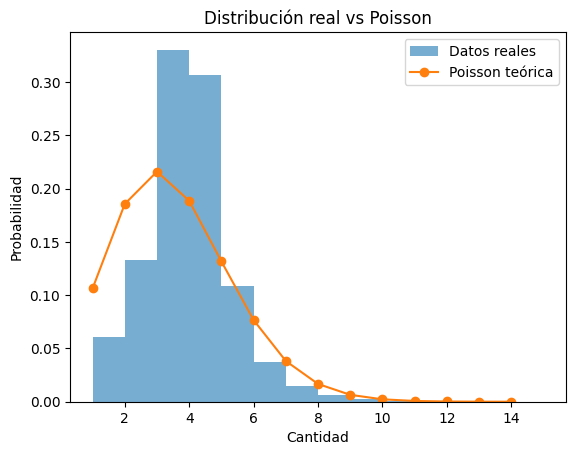

3.491614375356532
1.7469915171826091


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
df = pd.read_csv("enemdu_vivienda_hogar_2026_02.csv", sep=";")
variable = df["vi06"]

lambda_poisson = variable.mean()

print(lambda_poisson)
# Histograma de datos reales
plt.hist(variable,
         bins=range(int(variable.min()), int(variable.max()) + 2),
         density=True,
         alpha=0.6,
         label="Datos reales")

# Valores X
x = np.arange(variable.min(), variable.max() + 1)

# PMF de Poisson
pmf = poisson.pmf(x, lambda_poisson)

# Línea teórica
plt.plot(x, pmf, 'o-', label="Poisson teórica")

# Etiquetas
plt.xlabel("Cantidad")
plt.ylabel("Probabilidad")
plt.title("Distribución real vs Poisson")
plt.legend()

plt.show()

media = variable.mean()
varianza = variable.var()
print(media)
print(varianza)

---

## **Tarea 4: ABI - Aproximación Binomial a Poisson**

Investigue bajo qué condiciones matemáticas una distribución Binomial se aproxima a una de Poisson.

Redacte un bloque **Markdown** explicando la relación $\lambda = n \cdot p$ cuando $n \to \infty$ y $p \to 0$.





## Aproximación de la Distribución Binomial a la Distribución de Poisson

La distribución Binomial puede aproximarse a una distribución de Poisson bajo ciertas condiciones específicas. Esta aproximación ocurre cuando:

- El número de ensayos $n$ tiende a infinito ($n \to \infty$)
- La probabilidad de éxito $p$ tiende a cero ($p \to 0$)
- El producto $\lambda = n \cdot p$ se mantiene constante

Bajo estas condiciones, la variable aleatoria binomial:

$$
X \sim Binomial(n, p)
$$

se aproxima a una variable aleatoria de Poisson:

$$
X \sim Poisson(\lambda)
$$

Esto significa que la probabilidad de obtener exactamente $k$ éxitos en la distribución Binomial es aproximadamente igual a la probabilidad en la distribución de Poisson:

$$
P(X = k) \approx \frac{e^{-\lambda} \lambda^k}{k!}
$$

### Interpretación

Esta aproximación es útil en situaciones donde se modelan eventos raros, es decir, eventos con baja probabilidad de ocurrencia pero con un gran número de intentos, como fallos en sistemas, accidentes o errores en procesos.

En la práctica, esta relación simplifica los cálculos, ya que la distribución de Poisson es más fácil de manejar cuando $n$ es grande y $p$ es pequeño.

## Relación cuando $n \to \infty$ y $p \to 0$

La relación entre la distribución Binomial y la distribución de Poisson se basa en un comportamiento límite. Cuando el número de ensayos $n$ tiende a infinito ($n \to \infty$) y la probabilidad de éxito $p$ tiende a cero ($p \to 0$), de tal manera que el producto $\lambda = n \cdot p$ permanece constante, la distribución Binomial converge a una distribución de Poisson.

Matemáticamente, esto se expresa como:

$$
\lim_{n \to \infty, \; p \to 0} Binomial(n, p) = Poisson(\lambda)
$$

Esto significa que, bajo estas condiciones, la probabilidad de obtener un número específico de éxitos en la distribución Binomial es prácticamente igual a la obtenida mediante una distribución de Poisson con parámetro $\lambda$.

Este resultado es fundamental en estadística, ya que permite simplificar el cálculo de probabilidades cuando se trabaja con un gran número de ensayos y eventos de baja probabilidad.

Escriba un pequeño script en Python que calcule $P(X = 5)$ usando un modelo Binomial con $n = 1000$ y $p = 0.003$, y compare el resultado imprimiendo también el valor de $P(X = 5)$ en un modelo de Poisson donde $\lambda = 1000 \cdot 0.003 = 3$. Demuestre que los valores son casi idénticos.

In [3]:
from scipy.stats import binom, poisson

# Parámetros
n = 1000        # grande
p = 0.01        # pequeño
lam = n * p     # λ constante

k = 5           # valor a evaluar

# Probabilidad Binomial
prob_binomial = binom.pmf(k, n, p)

# Probabilidad Poisson
prob_poisson = poisson.pmf(k, lam)

# Resultados
print(f"Binomial P(X={k}): {prob_binomial:.6f}")
print(f"Poisson  P(X={k}): {prob_poisson:.6f}")

Binomial P(X=5): 0.037453
Poisson  P(X=5): 0.037833


---

## **7. Preguntas de Control:**

*   **Matemáticamente y conceptualmente**, ¿por qué la Función de Distribución Acumulada (CDF) de una variable aleatoria discreta tiene una gráfica en forma de "escalera" (step function) a diferencia de las funciones continuas?

  La Función de Distribución Acumulada (CDF) de una variable aleatoria discreta tiene forma de “escalera” porque las probabilidades solo se acumulan en valores específicos y separados de la variable.
  En una distribución discreta, la variable no puede tomar cualquier valor continuo, sino únicamente ciertos valores puntuales (por ejemplo: 0, 1, 2, 3…). Por ello, la CDF permanece constante entre un valor y otro y aumenta únicamente cuando se alcanza un punto con probabilidad positiva.
  Matemáticamente, la CDF se define como:

  F(x)=P(X≤x)

  Cada “salto” de la gráfica representa la probabilidad acumulada en ese valor específico. En cambio, en variables continuas la probabilidad se distribuye sobre intervalos y la función cambia de manera suave y continua.

*   Analizando los supuestos del experimento de Bernoulli, si extraemos cartas de una baraja sin reemplazo buscando ases, ¿podemos modelar este escenario con una distribución Binomial? Justifique estadísticamente su respuesta.

No, este escenario no puede modelarse exactamente con una distribución Binomial.
La distribución Binomial requiere que:

•	Los ensayos sean independientes.

•	La probabilidad de éxito p permanezca constante en cada intento.
Sin embargo, al extraer cartas de una baraja sin reemplazo:

•	Las extracciones no son independientes.
•	La probabilidad de obtener un as cambia después de cada extracción.

Por ejemplo, inicialmente la probabilidad es:

P(as)= 52/4

Pero si ya salió un as, la probabilidad cambia en la siguiente extracción. Por ello, el modelo correcto sería una distribución Hipergeométrica y no Binomial.
La aproximación Binomial solo sería aceptable si la población fuera muy grande comparada con la muestra, haciendo que el cambio en las probabilidades sea casi despreciable.

*   En la Tarea 3 de su proyecto (ABP), ¿qué limitaciones existen al asumir que la tasa media ($\lambda$) calculada de su dataset permanece constante a lo largo de todo el periodo de estudio? ¿Se cumple la propiedad de estacionariedad?

En la Tarea 3 se modeló la variable vi06 utilizando una distribución de Poisson, estimando el parámetro λ mediante la media de los datos:

lambda_poisson = variable.mean()

En una distribución de Poisson se asume que la tasa media de ocurrencia λ permanece constante durante todo el período de estudio. Sin embargo, esta suposición presenta varias limitaciones cuando se trabaja con datos reales.

Primero, los datos del dataset pueden presentar variaciones debido a factores sociales, económicos o regionales que hacen que la frecuencia de ocurrencia cambie en distintos grupos o momentos. Esto implica que la tasa media podría no ser completamente constante.

Además, el histograma comparado con la distribución teórica mostró similitudes generales, pero también diferencias en algunos valores debido a la dispersión de los datos reales. Esto indica que la distribución de Poisson no representa perfectamente el comportamiento observado.

La propiedad de estacionariedad implica que las características estadísticas del proceso, especialmente la media y la varianza, se mantienen estables en el tiempo. En este caso, no puede asegurarse completamente dicha propiedad, ya que el análisis realizado fue descriptivo y no incluyó pruebas formales de estacionariedad. Por ello, únicamente puede afirmarse que la variable presenta un comportamiento parcialmente compatible con un modelo de Poisson, pero con posibles variaciones en la tasa media λ.

*   A partir de la investigación en la Tarea 4 (ABI), ¿cuáles son los umbrales prácticos (valores comúnmente aceptados en la literatura estadística de $n$ y $p$) para considerar que la aproximación de Poisson a la Binomial es segura y válida?

A partir de la investigación realizada en la Tarea 4, la aproximación de la distribución Binomial a la distribución de Poisson se considera válida cuando el número de ensayos es grande y la probabilidad de éxito es pequeña, manteniendo constante el valor:

λ= np

En la práctica estadística, los criterios más utilizados para considerar segura esta aproximación son:

•	n≥20
•	p≤0.05
•	np≤10

Estas condiciones garantizan que los eventos sean raros, característica principal de la distribución de Poisson.

En la Tarea 4 se utilizó el ejemplo:

•	n=1000

•	p=0.01

por lo que:

λ= 1000(0.01) = 10

Al comparar las probabilidades calculadas mediante Binomial y Poisson para k=5, los resultados fueron muy similares, demostrando que la aproximación es adecuada bajo estas condiciones.

Además, teóricamente se cumple que cuando:

•	n→∞

•	p→0

la distribución Binomial converge a una distribución de Poisson, lo cual permite simplificar cálculos probabilísticos en eventos raros como fallos, accidentes o errores en procesos.

*   Si $X \sim \text{Poisson}(\lambda)$, sabemos teóricamente que $E[X] = \lambda$ y $V[X] = \lambda$. ¿Se cumple esta propiedad (media igual a varianza) en la variable de conteo que extrajo de su dataset regional? Calcule ambos estadísticos muestrales y comente.

En una distribución de Poisson se cumple teóricamente que la media y la varianza son iguales:

E[X]=V[X]=λ

En el análisis realizado sobre la variable de conteo del dataset regional se obtuvieron los siguientes valores:

Media: 3.4916

Varianza: 1.7470

Al comparar ambos resultados, se observa que la media y la varianza no son iguales ni suficientemente cercanas, ya que la varianza es considerablemente menor que la media.

Por lo tanto, la propiedad característica de la distribución de Poisson no se cumple completamente en esta variable del dataset. Esto indica que los datos reales presentan un comportamiento diferente al modelo teórico de Poisson, posiblemente debido a factores de dispersión, heterogeneidad en los datos o variaciones en la tasa de ocurrencia.

Sin embargo, aunque no se cumple exactamente la igualdad entre media y varianza, la distribución de Poisson puede seguir utilizándose como una aproximación parcial para describir el comportamiento general de la variable.

